# Detection of Male and Female Eyes from image Dataset

## Using CNN

In [9]:
# pip install keras_preprocessing

In [10]:
!pip install keras_preprocessing
# Import the required modules
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


# Use Dataset from https://www.kaggle.com/datasets/pavelbiz/eyes-rtte

### This Dataset contains ~11K images of human eye photographs separated into two directories
#### Complete this notebook to demonstrates training and testing a simple keras binary classification CNN

In [1]:
# ! pip install kaggle

In [2]:
! kaggle datasets download pavelbiz/eyes-rtte

Dataset URL: https://www.kaggle.com/datasets/pavelbiz/eyes-rtte
License(s): copyright-authors
100% 40.4M/40.4M [00:00<00:00, 114MB/s]



In [3]:
!mkdir /content/eyes_dataset2
! mkdir train_eye_dataset2

In [4]:
! unzip /content/eyes-rtte.zip -d /content/eyes_dataset2

Streaming output truncated to the last 5000 lines.
  inflating: /content/eyes_dataset2/maleeyes/2430.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2431.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2432.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2433.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2434.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2435.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2436.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2437.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2438.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2439.jpg  
  inflating: /content/eyes_dataset2/maleeyes/244.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2440.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2441.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2442.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2443.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2444.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2445.jpg 

In [12]:
import os
print(os.listdir('/content/eyes_dataset2'))

# Replace 'YOUR_DATASET_FOLDER' with the actual dataset
print(os.listdir('/content/eyes_dataset2'))


['maleeyes', 'femaleeyes']
['maleeyes', 'femaleeyes']


In [15]:
import os

print("Male images:",len(os.listdir('/content/eyes_dataset2/maleeyes')))

print("Female images:",len(os.listdir('/content/eyes_dataset2/femaleeyes')))


Male images: 6323
Female images: 5202


In [16]:
dataset_path = '/content/eyes_dataset2'

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 9221 images belonging to 2 classes.
Found 2304 images belonging to 2 classes.


In [18]:
print(train_generator.class_indices)

{'femaleeyes': 0, 'maleeyes': 1}


In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout

model = Sequential()

model.add(Conv2D(16, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(GlobalAveragePooling2D())

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,697 (100.38 KB)

 Trainable params: 25,697 (100.38 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history=model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


289/289 ━━━━━━━━━━━━━━━━━━━━ 37s 122ms/step - accuracy: 0.5673 - loss: 0.6804 - val_accuracy: 0.5577 - val_loss: 0.6781


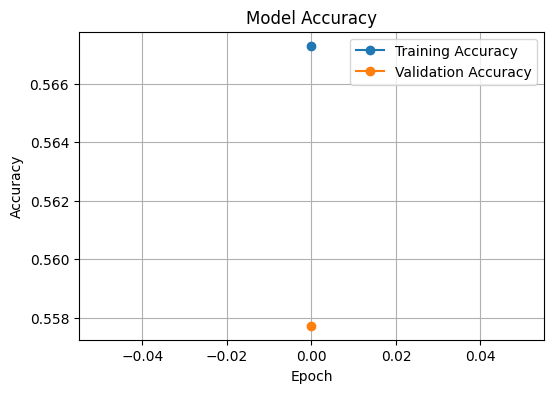

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

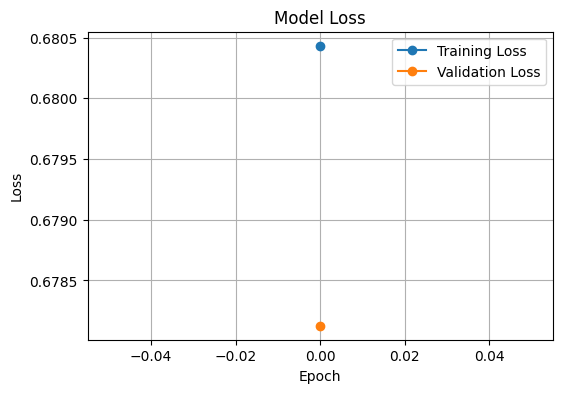

In [25]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [26]:
model.save("model.keras")
print(' model saved successfully')

 model saved successfully


In [27]:
loaded_model = tf.keras.models.load_model('model.keras')

print("model loaded succesfully")
print("Input Shape:", loaded_model.input_shape)
print("Output Shape:", loaded_model.output_shape)


model loaded succesfully
Input Shape: (None, 64, 64, 3)
Output Shape: (None, 1)


In [28]:
import os

size_mb = os.path.getsize("model.keras") / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")

Model size: 0.34 MB
